In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [39]:
### Constants

R = 1.66
SIGMA = 5.670374419e-8  # W m-2 K-4

# Q1
optical thickness at pressure p integrated downwards from teh TOA

In [40]:
def tau_p(t0,p,p0):
    return t0*p/p0

In [41]:
tau0 = 0.89
p0 = 100000 # pa
p = np.arange(0,100000)
tau = tau_p(tau0,p,p0)

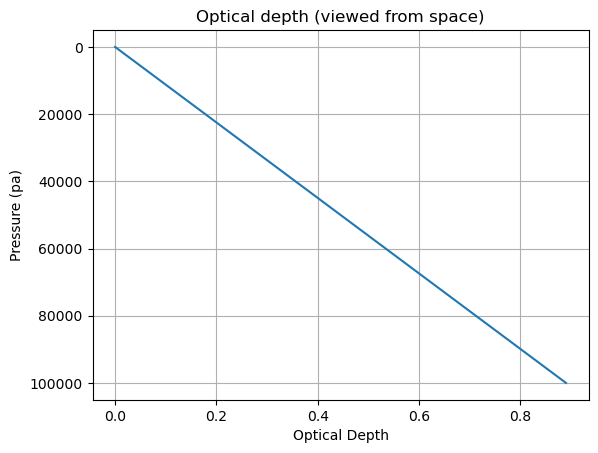

In [42]:
fig, ax = plt.subplots()

ax.plot(tau,p)
ax.set_xlabel("Optical Depth")
ax.set_ylabel('Pressure (pa)')
ax.set_title("Optical depth (viewed from space)")
ax.yaxis.set_inverted(True)
ax.grid()

# Q2
Layer emissivity

In [43]:
def emiss_layer(t0,p0,dp):
    return 1 - np.exp(-t0*dp*R/p0)

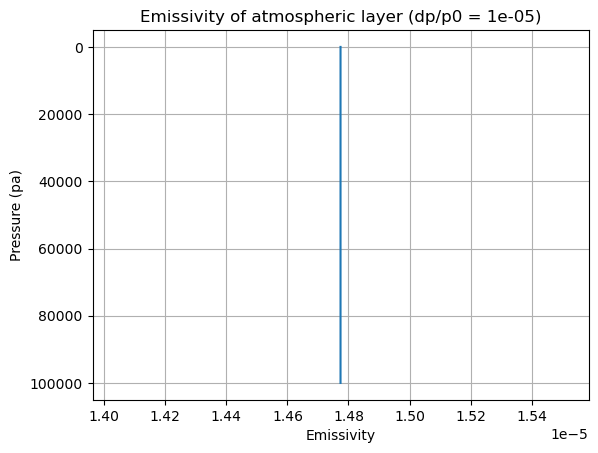

In [44]:
dp = np.diff(p).mean()
emiss_dp = emiss_layer(tau0,p0,dp = dp) * np.ones(len(p))

fig, ax = plt.subplots()

ax.plot(emiss_dp,p)
ax.set_xlabel("Emissivity")
ax.set_ylabel('Pressure (pa)')
ax.set_title(f"Emissivity of atmospheric layer (dp/p0 = {dp/p0})")
ax.yaxis.set_inverted(True)
ax.grid()

# Q3
Surface flux and transmitted surface flux

In [45]:
def black_body_irradiance(temp):
    return SIGMA * temp**4

def transmitted_sfc_flux(temp,t0,p0,p):
    bs = black_body_irradiance(temp)
    return bs*np.exp(-t0*R*(p0-p)/p0)

In [46]:
black_body_irradiance(288)

390.1051535418615

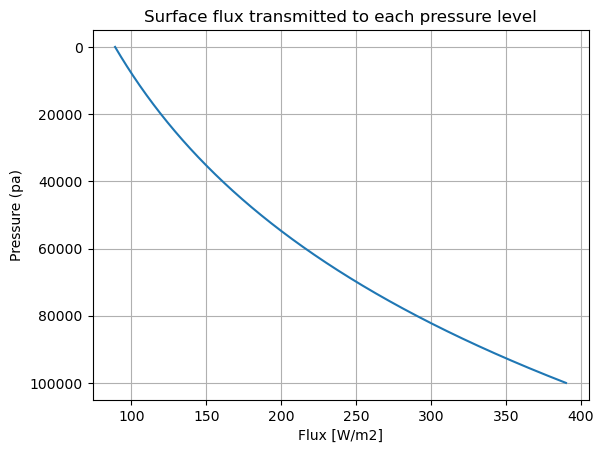

In [47]:
fsp = transmitted_sfc_flux(temp = 288,t0 = tau0,p0 = p0,p = p)

fig, ax = plt.subplots()

ax.plot(fsp,p)
ax.set_xlabel("Flux [W/m2]")
ax.set_ylabel('Pressure (pa)')
ax.set_title("Surface flux transmitted to each pressure level")
ax.yaxis.set_inverted(True)
ax.grid()

# Q4
Atmospheric flux transmitted to layer p

In [48]:
# atmospheric emission for single layer
black_body_irradiance(242.2)*0.772

150.6348960829733

In [49]:
def flux_atm_up(temp,t0,p0,p):
    # dp = np.diff(p).mean()
    # layer_e = emiss_layer(tau0,p0,dp = dp)
    # ba = black_body_irradiance(temp)*layer_e
    # return ba*np.arange(len(p),0,-1)
    ba = black_body_irradiance(temp)
    return ba*(1 - np.exp(-t0*R*(p0-p)/p0))

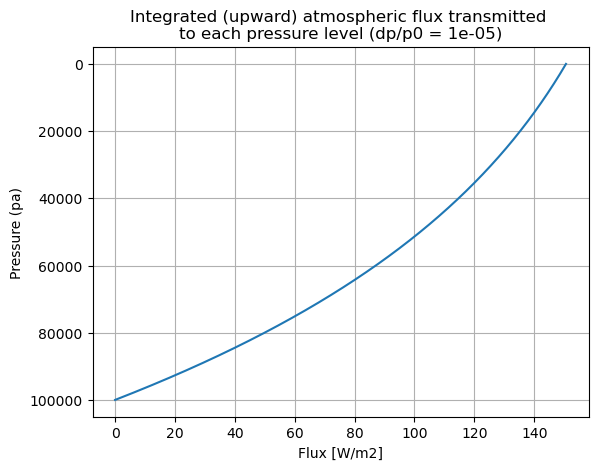

In [50]:
fau = flux_atm_up(temp=242.2,t0=tau0,p0=p0,p=p)

fig, ax = plt.subplots()

ax.plot(fau,p)
ax.set_xlabel("Flux [W/m2]")
ax.set_ylabel('Pressure (pa)')
ax.set_title(f"Integrated (upward) atmospheric flux transmitted \nto each pressure level (dp/p0 = {dp/p0})")
ax.yaxis.set_inverted(True)
ax.grid()

In [51]:
def flux_atm_down(temp,t0,p0,p):
    # dp = np.diff(p).mean()
    # layer_e = emiss_layer(tau0,p0,dp = dp)
    # ba = black_body_irradiance(temp)*layer_e
    # return -ba*np.arange(0,len(p))
    ba = black_body_irradiance(temp)
    return ba*(np.exp(-t0*R*p/p0)-1)


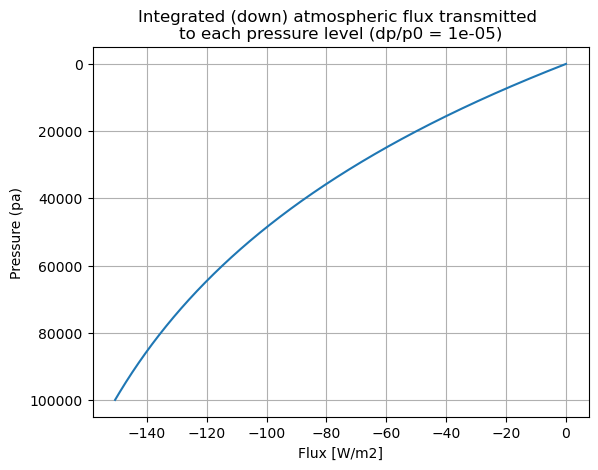

In [52]:
fad = flux_atm_down(temp=242.2,t0=tau0,p0=p0,p=p)

fig, ax = plt.subplots()

ax.plot(fad,p)
ax.set_xlabel("Flux [W/m2]")
ax.set_ylabel('Pressure (pa)')
ax.set_title(f"Integrated (down) atmospheric flux transmitted \nto each pressure level (dp/p0 = {dp/p0})")
ax.yaxis.set_inverted(True)
ax.grid()

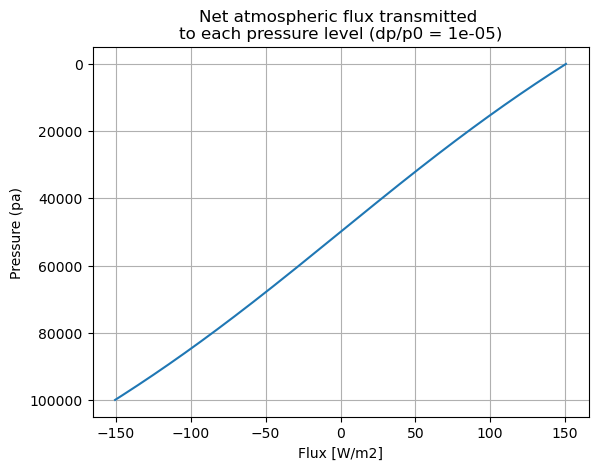

In [53]:
fan = fau + fad
fig, ax = plt.subplots()

ax.plot(fan,p)
ax.set_xlabel("Flux [W/m2]")
ax.set_ylabel('Pressure (pa)')
ax.set_title(f"Net atmospheric flux transmitted \nto each pressure level (dp/p0 = {dp/p0})")
ax.yaxis.set_inverted(True)
ax.grid()

In [54]:
print(f"Net atmospheric flux at p=0 Pa: {fan[-1]}")
print(f"Net atmospheric flux at p={p0} Pa: {fan[0]}")

Net atmospheric flux at p=0 Pa: -150.58641540328918
Net atmospheric flux at p=100000 Pa: 150.58995606295443


The answer would be different from 4a if we did not assume an isothermal atmosphere. 

# Q5

In [55]:
def net_lw_rad_flux(temp_sfc,temp_atm,t0,p0,p):
    sfc_up = transmitted_sfc_flux(temp_sfc,t0,p0,p)
    atm_up = flux_atm_up(temp_atm,t0,p0,p)
    atm_down = flux_atm_down(temp_atm,t0,p0,p)
    return sfc_up + atm_up + atm_down

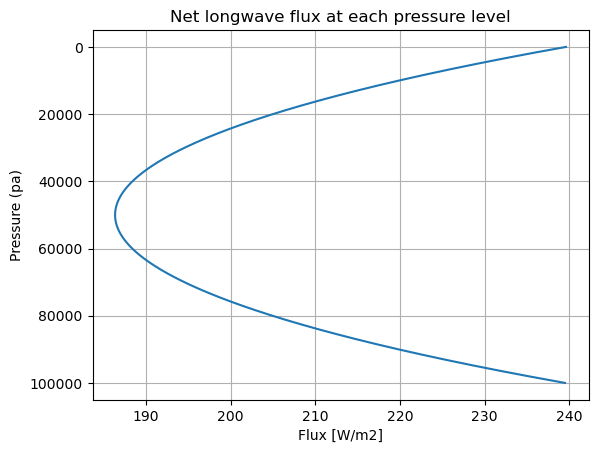

In [56]:
net_lw_flux = net_lw_rad_flux(temp_sfc = 288,temp_atm = 242.2,t0 = tau0,p0 = p0,p = p)
fig, ax = plt.subplots()

ax.plot(net_lw_flux,p)
ax.set_xlabel("Flux [W/m2]")
ax.set_ylabel('Pressure (pa)')
ax.set_title("Net longwave flux at each pressure level")
ax.yaxis.set_inverted(True)
ax.grid()

In [57]:
def flux_convergence(temp_sfc,temp_atm,t0,p0,p):
    b_sfc = black_body_irradiance(temp_sfc)
    b_atm = black_body_irradiance(temp_atm)
    # return b_sfc*t0*R/p0*np.exp(-t0*R/p0*(p0-p)) - b_atm*t0*R/p0*np.exp(-t0*R/p0*(p0-p)) + b_atm*t0*R/p0*np.exp(-t0*R*p/p0)
    ### NOT RIGHT ### just taking gradient of prior function instead
    return -(t0*R/p0*(b_sfc*np.exp(-t0*R/p0*(p0-p)) - b_atm*(np.exp(-t0*R/p0*(p0-p)) - np.exp(-t0*R*p/p0))))

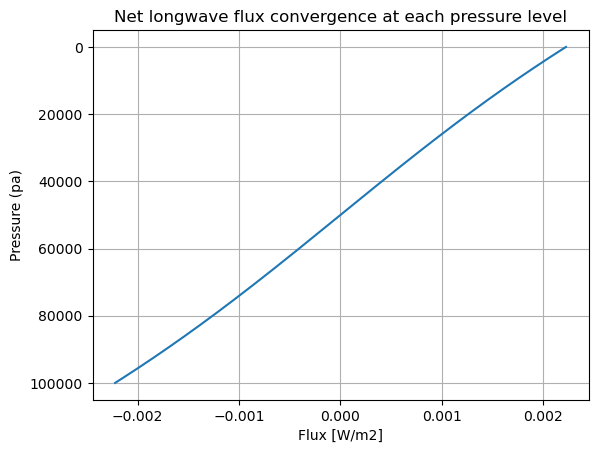

In [58]:
# flux_conv = flux_convergence(temp_sfc = 288,temp_atm = 242.2,t0 = tau0,p0 = p0,p = p)
flux_conv = -np.gradient(net_lw_flux)
fig, ax = plt.subplots()

ax.plot(flux_conv,p)
ax.set_xlabel("Flux [W/m2]")
ax.set_ylabel('Pressure (pa)')
ax.set_title("Net longwave flux convergence at each pressure level")
ax.yaxis.set_inverted(True)
ax.grid()

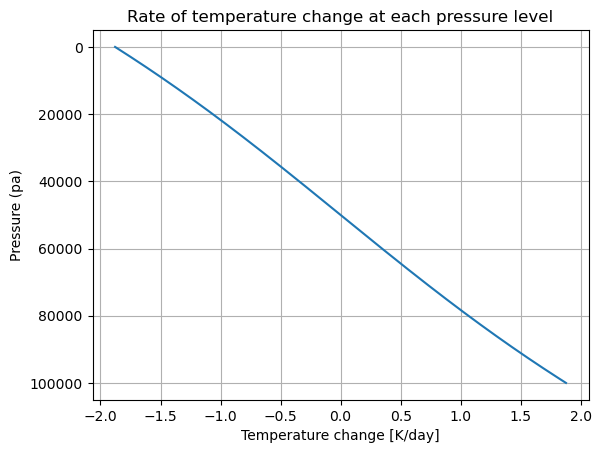

In [59]:
g = 9.81
cp = 1004
seconds_in_day = 60*60*24
dT_dt = flux_conv*-g/cp*seconds_in_day
fig, ax = plt.subplots()

ax.plot(dT_dt,p)
ax.set_xlabel("Temperature change [K/day]")
ax.set_ylabel('Pressure (pa)')
ax.set_title("Rate of temperature change at each pressure level")
ax.yaxis.set_inverted(True)
ax.grid()

In [60]:
def flux_atm_up_noniso(temp_profile, t0, p0, p):
    """Upward atmospheric flux at each level p for non-isothermal atmosphere."""
    n = len(p)
    kernel_factor = t0 * R / p0
    F_up = np.zeros(n)
    for i, pi in enumerate(p):
        # Integrate contributions from layers below pi (p' > pi)
        p_below = p[i:]          # pressure levels below level i (higher pressure)
        T_below = temp_profile[i:]
        B_below = black_body_irradiance(T_below)
        transmittance = np.exp(-kernel_factor * (p_below - pi))
        F_up[i] = np.trapezoid(B_below * kernel_factor * transmittance, p_below)
    return F_up

def flux_atm_down_noniso(temp_profile, t0, p0, p):
    """Downward atmospheric flux at each level p (negative = downward)."""
    n = len(p)
    kernel_factor = t0 * R / p0
    F_down = np.zeros(n)
    for i, pi in enumerate(p):
        # Integrate contributions from layers above pi (p' < pi)
        p_above = p[:i+1]        # pressure levels above level i (lower pressure)
        T_above = temp_profile[:i+1]
        B_above = black_body_irradiance(T_above)
        transmittance = np.exp(-kernel_factor * (pi - p_above))
        F_down[i] = -np.trapezoid(B_above * kernel_factor * transmittance, p_above)
    return F_down

def net_lw_rad_flux_noniso(temp_sfc, temp_profile, t0, p0, p):
    sfc_up  = transmitted_sfc_flux(temp_sfc, t0, p0, p)
    atm_up  = flux_atm_up_noniso(temp_profile, t0, p0, p)
    atm_down = flux_atm_down_noniso(temp_profile, t0, p0, p)
    return sfc_up + atm_up + atm_down


Converged at iteration 3299


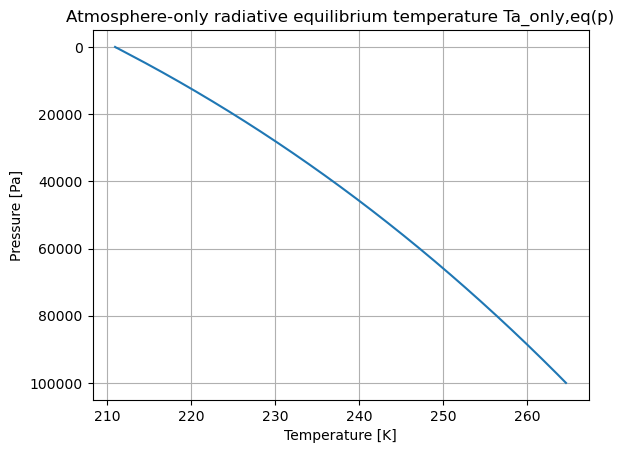

In [61]:
g = 9.81
cp = 1004
dt = 60*60
n_iter = 10000
tol = 1e-4 # K/day convergence threshold

# Use coarser grid to keep loop fast (p is 100k points — very slow)
p_coarse = np.linspace(0, p0, 500)      # 500-level grid is much faster

atm_profile = np.ones(len(p_coarse)) * 242.2

# Plot equilibrium profile
fig, ax = plt.subplots()

for i in range(n_iter):
    # ax.plot(atm_profile, p_coarse)

    F = net_lw_rad_flux_noniso(288, atm_profile, tau0, p0, p_coarse)
    dFdp = -np.gradient(F, p_coarse)
    dTdt = -g / cp * dFdp               # K/s
    delta_T = dTdt * dt
    atm_profile = atm_profile + delta_T
    if np.max(np.abs(delta_T)) < tol:
        print(f"Converged at iteration {i}")
        break

ax.plot(atm_profile, p_coarse)  
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Pressure [Pa]")
ax.set_title("Atmosphere-only radiative equilibrium temperature Ta_only,eq(p)")
ax.yaxis.set_inverted(True)
ax.grid()


In [62]:
p_coarse[:int(len(p_coarse)/2 + 1)]
atm_profile[int(len(p_coarse)/2 )]

np.float64(242.24723017206207)

# Q6

Converged at iteration 4363


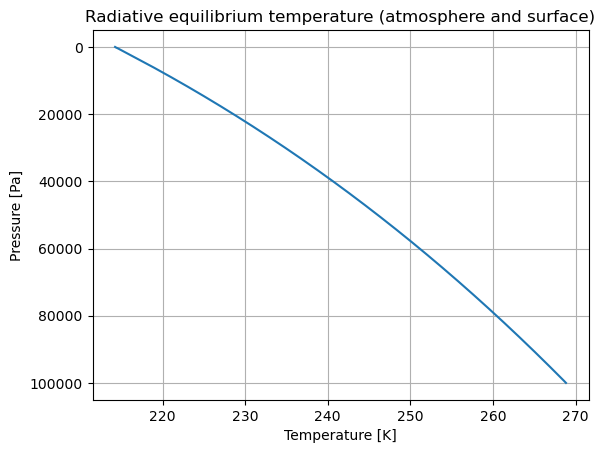

In [77]:
# g = 9.81
# cp = 1004
# dt = 60*60
# n_iter = 10000
# tol = 1e-4 # K/day convergence threshold
cp_water = 4184 # J⋅kg−1⋅K−1
rho = 1000 # kg/m3
h = 1 # m

Fsw = -239.4 # W/m2

sfc_temp = 288 # initial surface temperature

# Use coarser grid to keep loop fast (p is 100k points — very slow)
p_coarse = np.linspace(0, p0, 500)      # 500-level grid is much faster

atm_profile = np.ones(len(p_coarse)) * 242.2

# Plot equilibrium profile
fig, ax = plt.subplots()

for i in range(n_iter):
    # ax.plot(atm_profile, p_coarse)

    F = net_lw_rad_flux_noniso(sfc_temp, atm_profile, tau0, p0, p_coarse)
    dFdp = -np.gradient(F, p_coarse)
    dTdt = -g / cp * dFdp               # K/s
    delta_T = dTdt * dt
    atm_profile = atm_profile + delta_T

    # surface temp change
    dTsdt = -(Fsw + F[-1])/(cp_water*rho*h)
    delta_Ts = dTsdt * dt
    sfc_temp = sfc_temp + delta_Ts


    if np.max(np.abs(delta_T)) < tol:
        print(f"Converged at iteration {i}")
        break

ax.plot(atm_profile, p_coarse)  
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Pressure [Pa]")
ax.set_title("Radiative equilibrium temperature (atmosphere and surface)")
ax.yaxis.set_inverted(True)
ax.grid()



In [78]:
sfc_temp

np.float64(292.6528396761771)

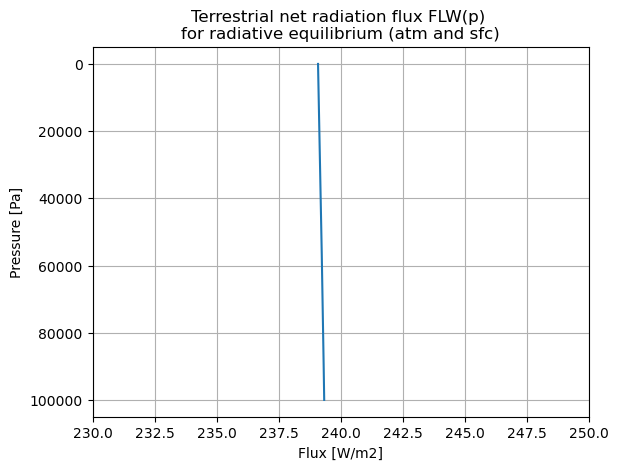

In [79]:
fig, ax = plt.subplots()

ax.plot(F, p_coarse)  
ax.set_xlabel("Flux [W/m2]")
ax.set_ylabel("Pressure [Pa]")
ax.set_title("Terrestrial net radiation flux FLW(p) \nfor radiative equilibrium (atm and sfc)")
ax.yaxis.set_inverted(True)
ax.set_xlim(230,250)
ax.grid()

# Q7

/var/folders/ys/qmftlyyx3dj63021dv4205g80000gn/T/ipykernel_78450/416378274.py:3: RuntimeWarning: divide by zero encountered in log
  z_coarse = -H*np.log(p_coarse/p0)


(0.0, 56000.0)

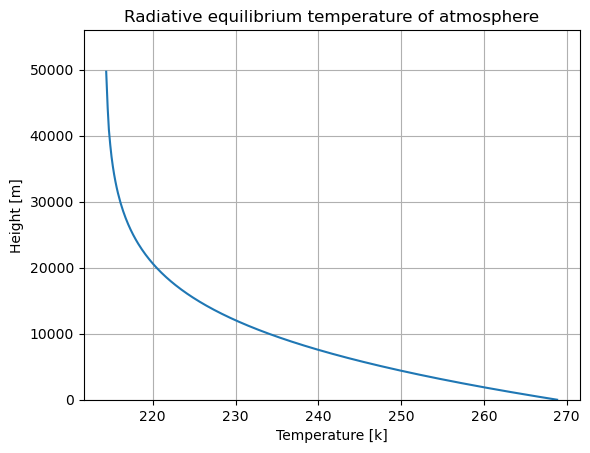

In [66]:
H = 8000
p_coarse
z_coarse = -H*np.log(p_coarse/p0)

fig, ax = plt.subplots()

ax.plot(atm_profile, z_coarse)  
ax.set_xlabel("Temperature [k]")
ax.set_ylabel("Height [m]")
ax.set_title("Radiative equilibrium temperature of atmosphere")
# ax.yaxis.set_inverted(True)
ax.grid()
ax.set_ylim(0,7*H)

In [67]:
atm_1xco2 = atm_profile

In [68]:
254.9/2**(1/4)

214.34449624817185

In [69]:
-(atm_profile[z_coarse < 7*H][0] - atm_profile[z_coarse < 7*H][1])/((z_coarse[z_coarse < 7*H]/1000)[0]-(z_coarse[z_coarse < 7*H]/1000)[1])

np.float64(0.03264947404310932)

# Q8

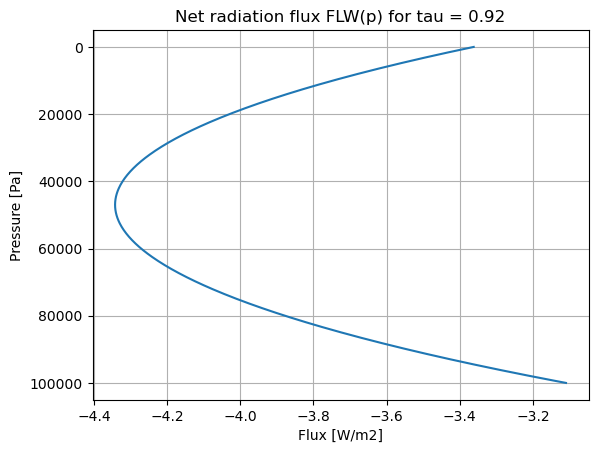

In [70]:
net_flux = net_lw_rad_flux_noniso(temp_sfc = sfc_temp, temp_profile = atm_profile, t0=0.92, p0=p_coarse[-1], p=p_coarse) + Fsw

fig, ax = plt.subplots()

ax.plot(net_flux, p_coarse)  
ax.set_xlabel("Flux [W/m2]")
ax.set_ylabel("Pressure [Pa]")
ax.set_title("Net radiation flux FLW(p) for tau = 0.92")
ax.yaxis.set_inverted(True)
ax.grid()

In [71]:
net_flux[0]

np.float64(-3.3621757960407024)

Converged at iteration 2671


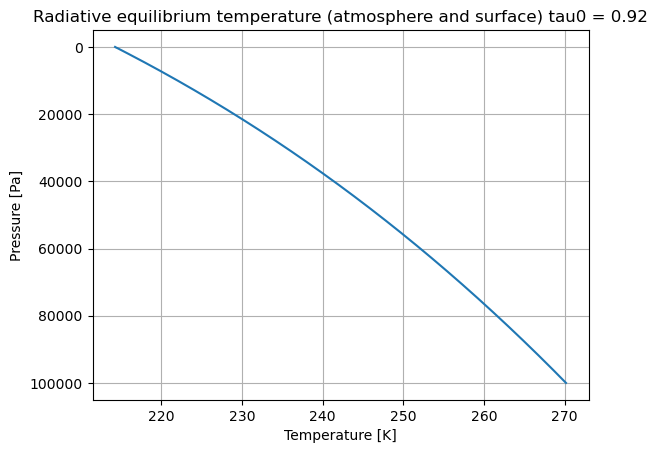

In [72]:
# Plot equilibrium profile
fig, ax = plt.subplots()

for i in range(n_iter):
    # ax.plot(atm_profile, p_coarse)

    F = net_lw_rad_flux_noniso(sfc_temp, atm_profile, 0.92, p0, p_coarse)
    dFdp = -np.gradient(F, p_coarse)
    dTdt = -g / cp * dFdp               # K/s
    delta_T = dTdt * dt
    atm_profile = atm_profile + delta_T

    # surface temp change
    dTsdt = -(Fsw + F[-1])/(cp_water*rho*h)
    delta_Ts = dTsdt * dt
    sfc_temp = sfc_temp + delta_Ts


    if np.max(np.abs(delta_T)) < tol:
        print(f"Converged at iteration {i}")
        break

ax.plot(atm_profile, p_coarse)  
ax.set_xlabel("Temperature [K]")
ax.set_ylabel("Pressure [Pa]")
ax.set_title("Radiative equilibrium temperature (atmosphere and surface) tau0 = 0.92")
ax.yaxis.set_inverted(True)
ax.grid()



In [73]:
atm_2xco2 = atm_profile

(0.0, 56000.0)

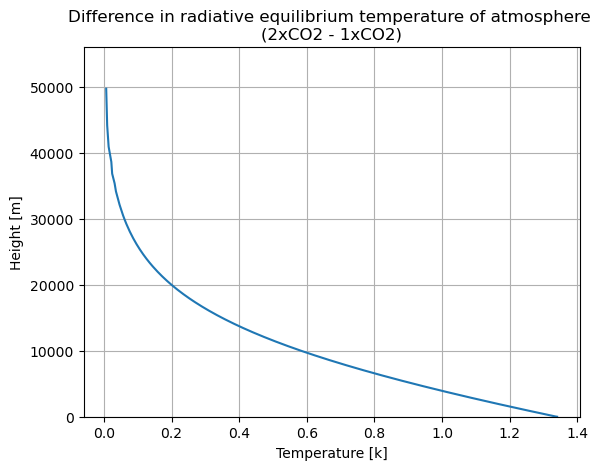

In [76]:
fig, ax = plt.subplots()

ax.plot(atm_2xco2 - atm_1xco2, z_coarse) 
# ax.plot(, z_coarse,label='2xCO2')  
ax.set_xlabel("Temperature [k]")
ax.set_ylabel("Height [m]")
ax.set_title("Difference in radiative equilibrium temperature of atmosphere \n(2xCO2 - 1xCO2)")
# ax.yaxis.set_inverted(True)
ax.grid()
ax.set_ylim(0,7*H)
# ax.legend()